# Online Retail Market Analysis
### Performed by William H. Ongseputra

## Foundational Python for Data Analysis 
This notebook was constructed as the **capstone project** for the Data Analysis Bootcamp at **Digica Academy**. It demonstrates a foundational application of Python (*Pandas, Seaborn*) to solve real-world business problems, specifically focusing on cohort analysis and customer segmentation. 

The dataset was sourced from Kaggle (**Online Retail II UCI**).

### Preprocessing: Import Libraries and Dataset and clean the data

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings; warnings.filterwarnings('ignore')

print(sns.__version__)

0.13.2


In [2]:
# First, install the kagglehub package
!pip install kagglehub

# Then import and use it
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\willi\.cache\kagglehub\datasets\mashlyn\online-retail-ii-uci\versions\3


In [3]:
# Import the os module first
import os

# List files in the downloaded directory to see what's available
print("Files in the directory:", os.listdir(path))

Files in the directory: ['online_retail_II.csv']


In [4]:
file_path = os.path.join(path, "online_retail_II.csv")  # Adjust filename as needed

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)  # Use pd.read_excel() if it's an Excel file

# Display the first few rows to verify
print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [5]:
#check for missing values
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [6]:
# df.shape returns a tuple (rows, columns)
rows, columns = df.shape
print(f"Total number of rows: {rows}")
print(f"Total number of columns: {columns}")

Total number of rows: 1067371
Total number of columns: 8


In [7]:
# Check the number of rows before removing NA values
print(f"Number of rows before removing NA: {len(df)}")

# Remove rows where 'Description' is NA
# Note: In pandas, column names are case-sensitive, so adjust if needed
df = df.dropna(subset=['Description'])  # Use 'Description' if that's the actual column name

# Check the number of rows after removing NA values
print(f"Number of rows after removing NA: {len(df)}")

# Display the first few rows to verify
print(df.head())

# Verify that missing values under Description has been removed
df.isna().sum()

Number of rows before removing NA: 1067371
Number of rows after removing NA: 1062989
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    238625
Country             0
dtype: int64

In [8]:
# Fill missing Customer ID with 0 (note that this means all customers under 0 is blank as it is supposed to be unique)
df["Customer ID"] = df ["Customer ID"].fillna(0)
# Verify that missing values under Description has been removed
df.isna().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [9]:
# df.shape returns a tuple (rows, columns)
rows, columns = df.shape
print(f"Total number of rows: {rows}")
print(f"Total number of columns: {columns}")

Total number of rows: 1062989
Total number of columns: 8


In [10]:
# Check for zero or negative values in Quantity
negative_in_Quantity = df[df['Quantity'] <= 0]
negative_in_Quantity

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [11]:
# Check for zero or negative values in Price
negative_in_Price = df[df['Price'] <= 0]
negative_in_Price

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,0.0,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,0.0,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,0.0,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,0.0,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,0.0,United Kingdom
...,...,...,...,...,...,...,...,...
1060797,581213,22576,check,-30,2011-12-07 18:38:00,0.0,0.0,United Kingdom
1062371,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,0.0,United Kingdom
1063965,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,0.0,United Kingdom
1063966,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,0.0,United Kingdom


In [12]:
# Remove zero and negative Quantity and Price values
df_positive = df[df['Quantity'] > 0]
df_positive = df_positive[df_positive['Price'] > 0]

df_positive

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [13]:
#Check for outliers using IQR in Quantity
q1 = df_positive["Quantity"].quantile(0.25)
q3 = df_positive["Quantity"].quantile(0.75)

iqr = q3-q1 #Interquartile range
fence_low  = q1-1.5*iqr
fence_high = q3+1.5*iqr

df_positive.loc[(df_positive["Quantity"] < fence_low) | (df_positive["Quantity"] > fence_high)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
10,489435,22195,HEART MEASURING SPOONS LARGE,24,2009-12-01 07:46:00,1.65,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067337,581585,84945,MULTI COLOUR SILVER T-LIGHT HOLDER,24,2011-12-09 12:31:00,0.85,15804.0,United Kingdom
1067343,581585,21916,SET 12 RETRO WHITE CHALK STICKS,24,2011-12-09 12:31:00,0.42,15804.0,United Kingdom
1067344,581585,84692,BOX OF 24 COCKTAIL PARASOLS,25,2011-12-09 12:31:00,0.42,15804.0,United Kingdom
1067352,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom


In [14]:
# Modify percentile to safely remove data (<5% rows)
q1 = df_positive["Quantity"].quantile(0.10)
q3 = df_positive["Quantity"].quantile(0.90)

iqr = q3-q1 #Interquartile range
fence_low  = q1-1.5*iqr
fence_high = q3+1.5*iqr

df_positive.loc[(df_positive["Quantity"] < fence_low) | (df_positive["Quantity"] > fence_high)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
58,489438,20711,JUMBO BAG TOYS,60,2009-12-01 09:24:00,1.30,18102.0,United Kingdom
63,489438,84032A,CHARLIE+LOLA PINK HOT WATER BOTTLE,60,2009-12-01 09:24:00,1.90,18102.0,United Kingdom
66,489438,84519B,CARROT CHARLIE+LOLA COASTER SET,60,2009-12-01 09:24:00,2.40,18102.0,United Kingdom
67,489438,85132A,CHARLIE + LOLA BISCUITS TINS,60,2009-12-01 09:24:00,6.38,18102.0,United Kingdom
68,489438,85132C,CHARLIE AND LOLA FIGURES TINS,60,2009-12-01 09:24:00,6.40,18102.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067163,581566,23404,HOME SWEET HOME BLACKBOARD,144,2011-12-09 11:50:00,3.26,18102.0,United Kingdom
1067164,581567,21417,COCKLE SHELL DISH,84,2011-12-09 11:56:00,0.79,16626.0,United Kingdom
1067172,581567,21326,AGED GLASS SILVER T-LIGHT HOLDER,144,2011-12-09 11:56:00,0.55,16626.0,United Kingdom
1067207,581571,23167,SMALL CERAMIC TOP STORAGE JAR,96,2011-12-09 12:00:00,0.69,15311.0,United Kingdom


In [15]:
# Clean outliers based on Quantity
df_clean = df_positive.loc[(df["Quantity"] >= fence_low) & (df_positive["Quantity"] <= fence_high)]

df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [16]:
#Check for outliers using IQR in Price
q1 = df_clean["Price"].quantile(0.25)
q3 = df_clean["Price"].quantile(0.75)

iqr = q3-q1 #Interquartile range
fence_low  = q1-1.5*iqr
fence_high = q3+1.5*iqr

df_clean.loc[(df_clean["Price"] < fence_low) | (df_clean["Price"] > fence_high)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
35,489437,21360,JOY LARGE WOOD LETTERS,1,2009-12-01 09:08:00,9.95,15362.0,United Kingdom
38,489437,35400,WOODEN BOX ADVENT CALENDAR,2,2009-12-01 09:08:00,8.95,15362.0,United Kingdom
89,489439,POST,POSTAGE,3,2009-12-01 09:28:00,18.00,12682.0,France
126,489444,POST,POSTAGE,1,2009-12-01 09:55:00,141.00,12636.0,USA
131,489445,22180,RETRO SPOT LAMP,2,2009-12-01 09:57:00,9.95,17519.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067229,581578,POST,POSTAGE,3,2011-12-09 12:16:00,18.00,12713.0,Germany
1067247,581578,22622,BOX OF VINTAGE ALPHABET BLOCKS,6,2011-12-09 12:16:00,11.95,12713.0,Germany
1067313,581580,22894,TABLECLOTH RED APPLES DESIGN,2,2011-12-09 12:20:00,9.95,12748.0,United Kingdom
1067353,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom


In [17]:
# Modify percentile to safely remove data (<5% rows)
q1 = df_clean["Price"].quantile(0.10)
q3 = df_clean["Price"].quantile(0.90)

iqr = q3-q1 #Interquartile range
fence_low  = q1-1.5*iqr
fence_high = q3+1.5*iqr

df_clean.loc[(df_clean["Price"] < fence_low) | (df_clean["Price"] > fence_high)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
126,489444,POST,POSTAGE,1,2009-12-01 09:55:00,141.00,12636.0,USA
173,489447,POST,POSTAGE,1,2009-12-01 10:10:00,130.00,12362.0,Belgium
881,489537,21737,SET 3 WICKER LOG BASKETS,1,2009-12-01 12:14:00,19.95,14040.0,United Kingdom
1344,489562,84472,PINK AND LILAC QUILTED THROW,1,2009-12-01 13:07:00,45.95,17998.0,United Kingdom
1381,489566,85067,CREAM SWEETHEART WALL CABINET,2,2009-12-01 13:16:00,18.95,17742.0,United Kingdom
...,...,...,...,...,...,...,...,...
1066898,581498,22622,BOX OF VINTAGE ALPHABET BLOCKS,1,2011-12-09 10:26:00,20.79,0.0,United Kingdom
1066916,581498,22776,SWEETHEART 3 TIER CAKE STAND,1,2011-12-09 10:26:00,19.96,0.0,United Kingdom
1066920,581498,22838,3 TIER CAKE TIN RED AND CREAM,1,2011-12-09 10:26:00,29.17,0.0,United Kingdom
1066988,581498,84968e,SET OF 16 VINTAGE BLACK CUTLERY,1,2011-12-09 10:26:00,24.96,0.0,United Kingdom


In [18]:
# Clean outliers based on Price
df_clean = df_clean.loc[(df["Price"] >= fence_low) & (df_clean["Price"] <= fence_high)]

df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [19]:
# Create a filtered dataset excluding customer ID = 0 (needed to do any analysis concerning real customers)
df_filtered = df_clean[df_clean["Customer ID"] != 0]

df_filtered

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


### Now we have 2 dataframes ready to use:
#### df_clean = cleaned positive data containing all customers; 
#### df_filtered = cleaned positive data excluding null customers

### Task 1: Finding distribution of order sizes (in terms of total transaction value)

In [20]:
# Find the Total Price
df_clean['Total Price'] = df_clean['Quantity'] * df_clean['Price']
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total Price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85


In [21]:
# Find total price for each invoice
df1 = df_clean.groupby('Invoice').sum('Total Price').reset_index()
df1

,Invoice,Quantity,Price,Customer ID,Total Price
0,489434,166,32.65,104680.0,505.30
1,489435,60,10.50,52340.0,145.80
2,489436,193,70.88,248482.0,630.33
3,489437,145,83.45,353326.0,310.75
4,489438,406,20.87,181020.0,895.44
...,...,...,...,...,...
38015,581583,76,3.30,27554.0,124.60
38016,581584,48,1.85,13777.0,88.80
38017,581585,278,37.78,331884.0,329.05
38018,581586,66,20.23,52452.0,339.20


<Axes: xlabel='Total Price', ylabel='Density'>

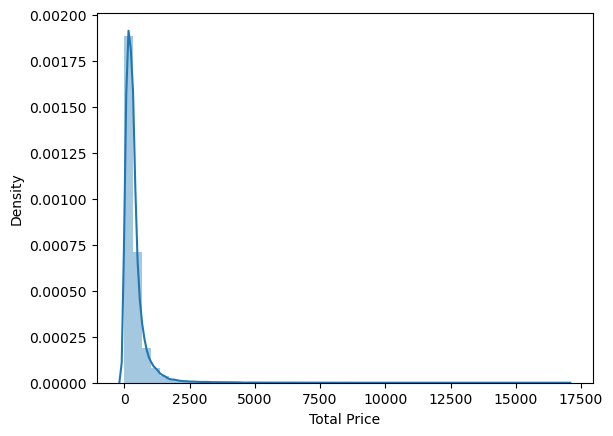

In [22]:
sns.distplot(df1['Total Price'])

### Task 2: Finding countries contribute the most to total revenue and what is the revenue share by country

In [23]:
df2 = df_clean.groupby('Country').sum('Total Price').reset_index()
df2

,Country,Quantity,Price,Customer ID,Total Price
0,Australia,19625,4173.660,1.576796e+07,5.361147e+04
1,Austria,10175,2396.830,1.096415e+07,1.837001e+04
2,Bahrain,1087,426.980,7.041870e+05,2.727590e+03
3,Belgium,32217,10652.250,3.757670e+07,6.103142e+04
4,Bermuda,494,84.280,0.000000e+00,7.693000e+02
5,Brazil,545,256.310,1.199170e+06,1.411870e+03
6,Canada,2864,505.880,3.748182e+06,3.737380e+03
7,Channel Islands,16539,5966.280,2.234858e+07,3.504571e+04
8,Cyprus,8258,4329.390,1.389927e+07,2.061305e+04
9,Czech Republic,526,37.690,2.811820e+05,7.449800e+02


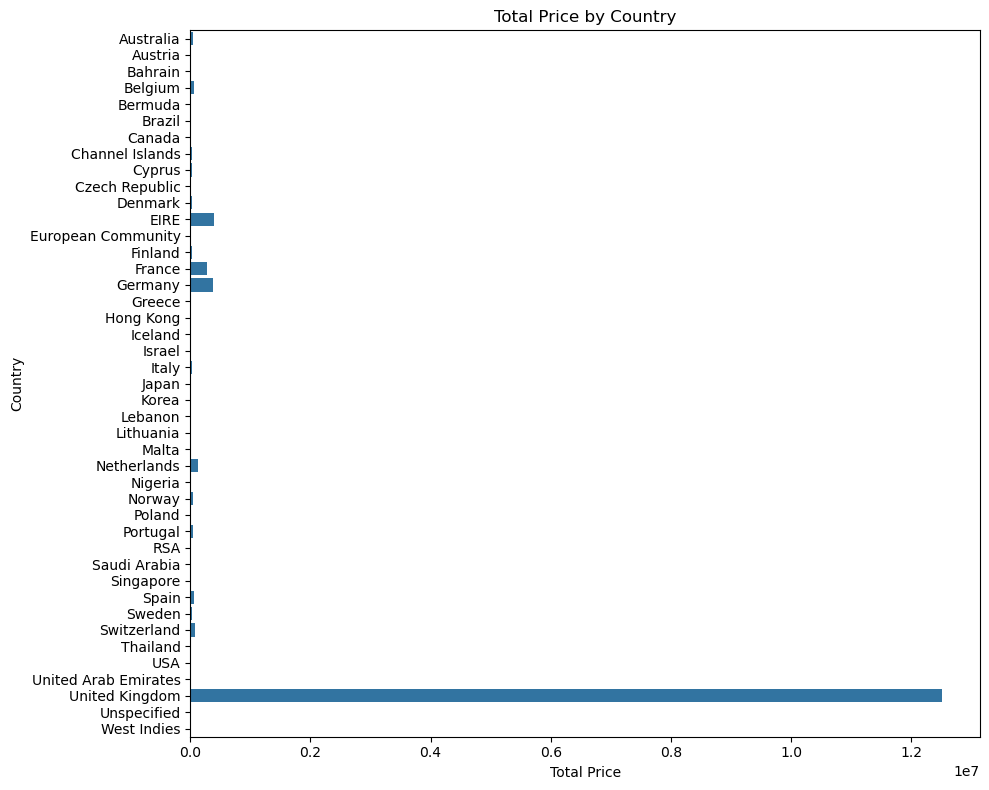

In [24]:
# Create horizontal bar plot by swapping x and y
plt.figure(figsize=(10, 8))  # Adjust figure size to better fit horizontal bars
sns.barplot(y='Country', x='Total Price', data=df2, ci=None)

# Improve readability
plt.title('Total Price by Country')
plt.xlabel('Total Price')
plt.ylabel('Country')
plt.tight_layout()  # Ensures everything fits well

# Display the plot
plt.show()

### Task 3: Finding our top customers by total spending, and how many orders have they placed (note: we will use _filtered in this case)

In [25]:
# Define the Total Price for df_filtered
df_filtered['Total Price'] = df_filtered['Quantity'] * df_filtered['Price']

# Group by CustomerID and calculate metrics
df3 = df_filtered.groupby('Customer ID').agg(
    TotalSpending=('Total Price', 'sum'),
    NumberOfOrders=('Invoice', 'nunique'),
)

# Calculate average order value
df3['AverageOrderValue'] = df3['TotalSpending'] / df3['NumberOfOrders']

# Round values for better readability (optional)
df3 = df3.round(2)

# Sort by total spending in descending order (optional)
df3 = df3.sort_values('TotalSpending', ascending=False)

# Display the first few rows
print(df3.head(20))

             TotalSpending  NumberOfOrders  AverageOrderValue
Customer ID                                                  
14911.0          249226.97             373             668.17
14646.0          105116.93             126             834.26
14156.0          102134.96             130             785.65
13089.0           99002.27             192             515.64
14298.0           72315.86              76             951.52
17511.0           69751.26              54            1291.69
17841.0           66147.06             210             314.99
15311.0           62596.57             204             306.85
17850.0           55384.58             155             357.32
14088.0           54021.37              16            3376.34
13081.0           52178.15              26            2006.85
14096.0           50992.54              17            2999.56
12748.0           45540.81             319             142.76
13093.0           42214.84              55             767.54
15061.0 

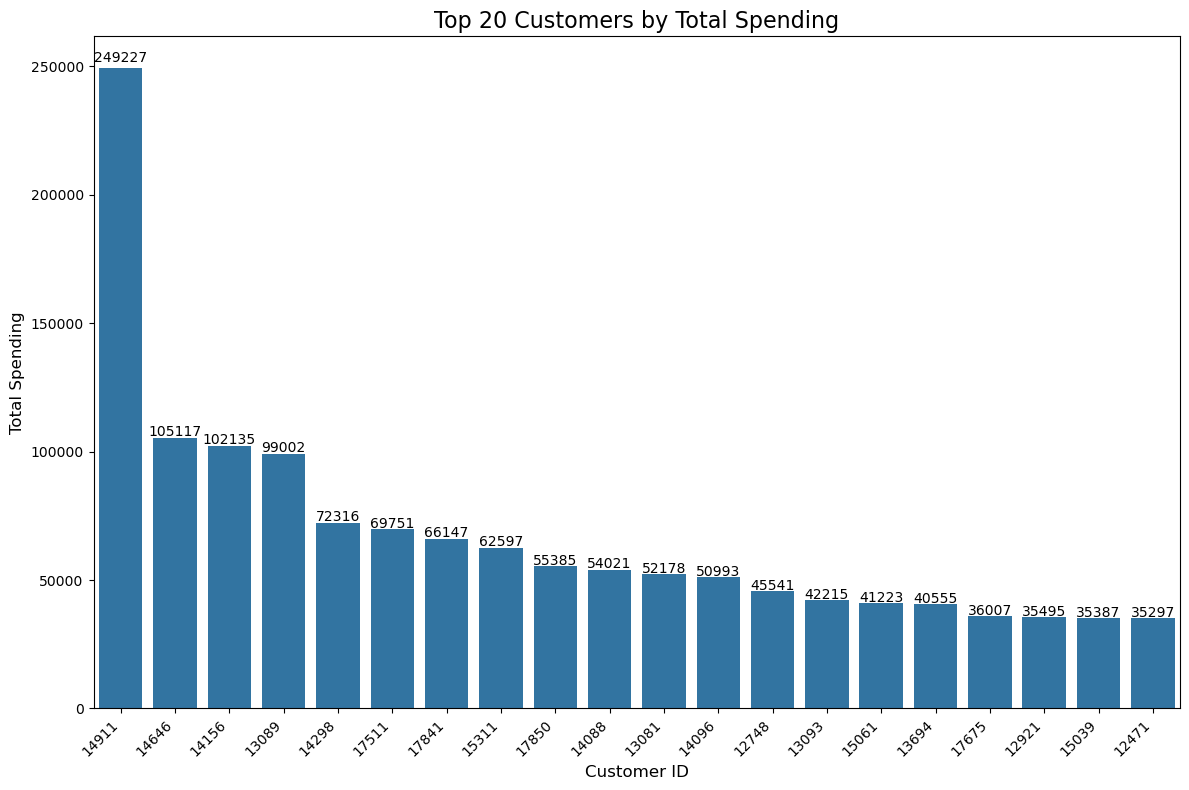

In [26]:
# Get the top 20 customers by total spending
top_20_customers = df3.sort_values('TotalSpending', ascending=False).head(20).copy()

# Round and Convert CustomerID to string to avoid numeric ordering
top_20_customers['Customer ID'] = top_20_customers.index.astype(int).astype(str)

# Create a categorical type with the specific order we want (highest spending first)
ordered_customers = pd.Categorical(
    top_20_customers['Customer ID'],
    categories=top_20_customers['Customer ID'].tolist(),
    ordered=True
)
top_20_customers['Customer ID'] = ordered_customers

# Create the bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x='Customer ID', y='TotalSpending', data=top_20_customers)

# Improve readability
plt.title('Top 20 Customers by Total Spending', fontsize=16)
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Total Spending', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate labels for better fit
plt.tight_layout()

# Add value labels on top of each bar (optional)
for i, v in enumerate(top_20_customers['TotalSpending']):
    plt.text(i, v + (v*0.01), f'{v:.0f}', ha='center')

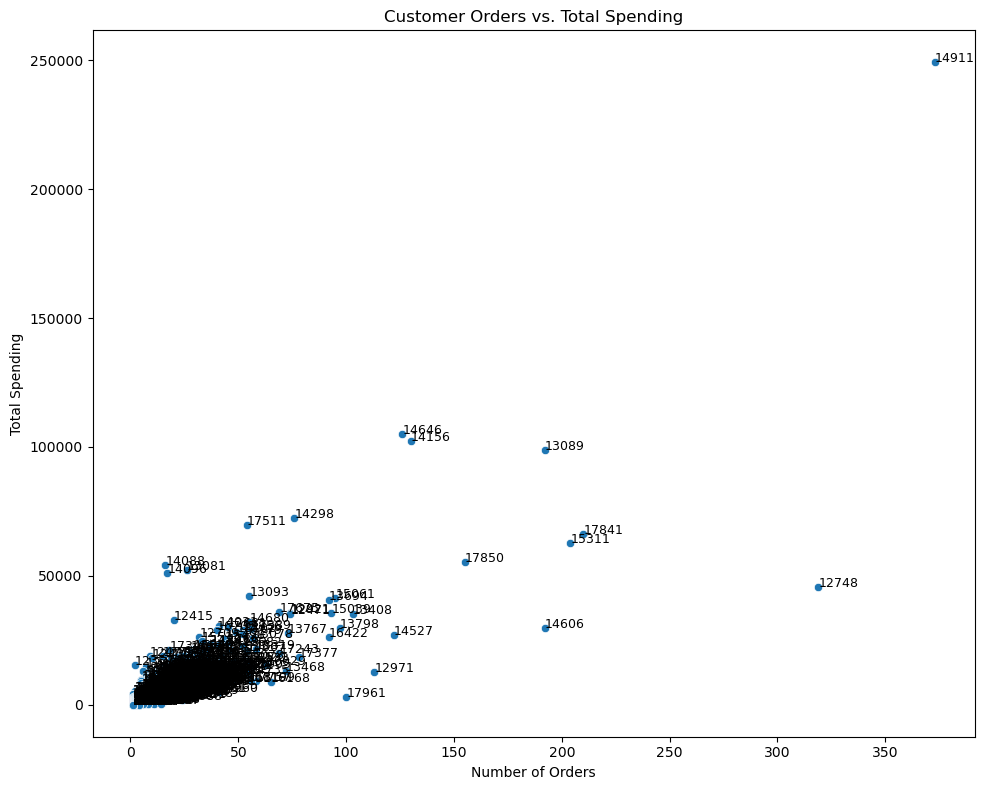

In [27]:
#Identify order pattern using scatterplot

# Create the basic scatterplot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='NumberOfOrders', y='TotalSpending', data=df3)

# Add labels next to each point
for idx, row in df3.iterrows():
    # Convert the index (CustomerID) to int then string to remove decimals
    customer_id = str(int(idx))
    plt.text(row['NumberOfOrders'] + 0.1, row['TotalSpending'], 
             customer_id, 
             fontsize=9)

# Improve the plot
plt.title('Customer Orders vs. Total Spending')
plt.xlabel('Number of Orders')
plt.ylabel('Total Spending')
plt.tight_layout()

plt.show()

### Task 4: Finding products (by item description) which generate the highest revenue and which are the most frequently sold (by quantity). Also, identify difference between best-selling by volume vs by revenue.

In [28]:
df4 = df_clean.groupby('Description').agg(
    TotalSpending=('Total Price', 'sum'),
    TotalQuantity=('Quantity', 'sum'),
    NumberOfOrders=('Invoice', 'nunique'),
)

df4

,TotalSpending,TotalQuantity,NumberOfOrders
Description,,,
DOORMAT UNION JACK GUNS AND ROSES,1206.81,179,60
3 STRIPEY MICE FELTCRAFT,1211.98,612,128
4 PURPLE FLOCK DINNER CANDLES,588.91,351,57
50'S CHRISTMAS GIFT BAG LARGE,1927.63,1515,128
ANIMAL STICKERS,80.85,385,12
...,...,...,...
ZINC T-LIGHT HOLDER STARS SMALL,2955.71,3373,262
ZINC TOP 2 DOOR WOODEN SHELF,1511.80,244,48
ZINC WILLIE WINKIE CANDLE STICK,5358.73,5834,620


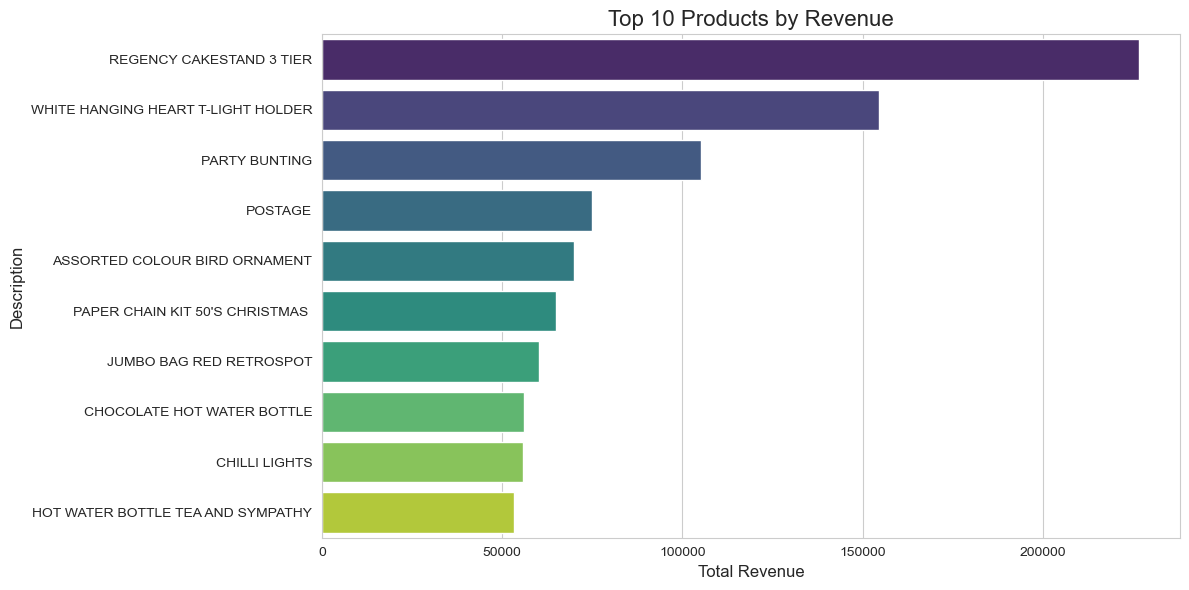

In [29]:
#sort and visualize

# Set the visual style
sns.set_style("whitegrid")

# 1. Bar chart of Top 10 Products by Revenue
# Sort by TotalSpending descending and take top 10
top_10_revenue = df4.sort_values('TotalSpending', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_revenue, x='TotalSpending', y=top_10_revenue.index, palette='viridis')
plt.title('Top 10 Products by Revenue', fontsize=16)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Description', fontsize=12)
plt.tight_layout()
plt.show()

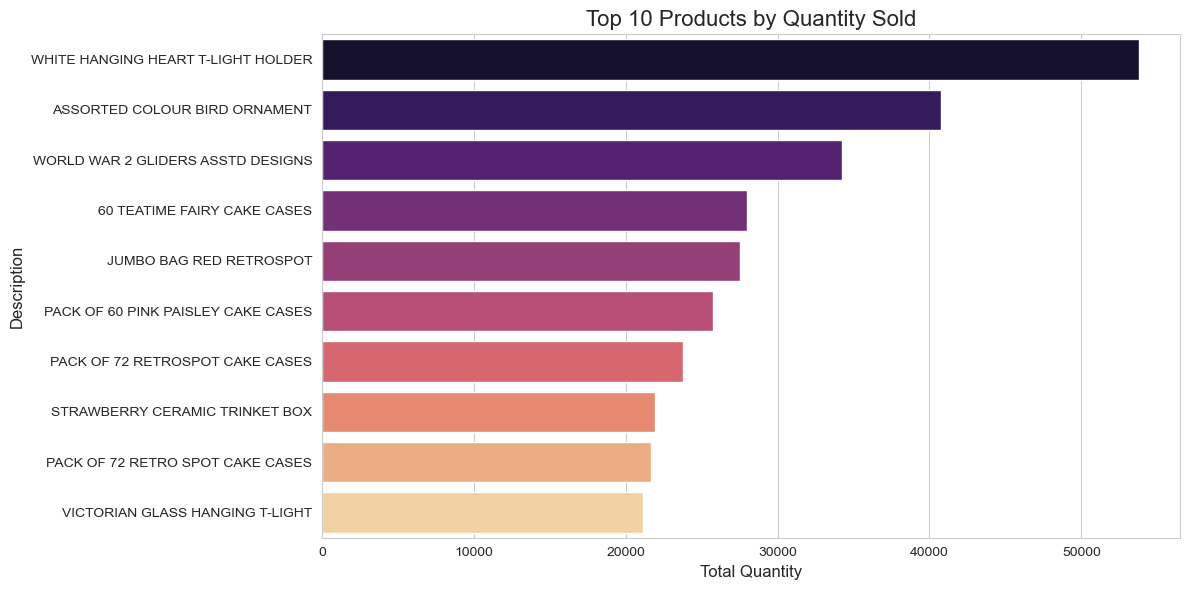

In [30]:
# 2. Bar chart of Top 10 Products by Quantity Sold
# Sort by TotalQuantity descending and take top 10
top_10_quantity = df4.sort_values('TotalQuantity', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_quantity, x='TotalQuantity', y=top_10_quantity.index, palette='magma')
plt.title('Top 10 Products by Quantity Sold', fontsize=16)
plt.xlabel('Total Quantity', fontsize=12)
plt.ylabel('Description', fontsize=12)
plt.tight_layout()
plt.show()


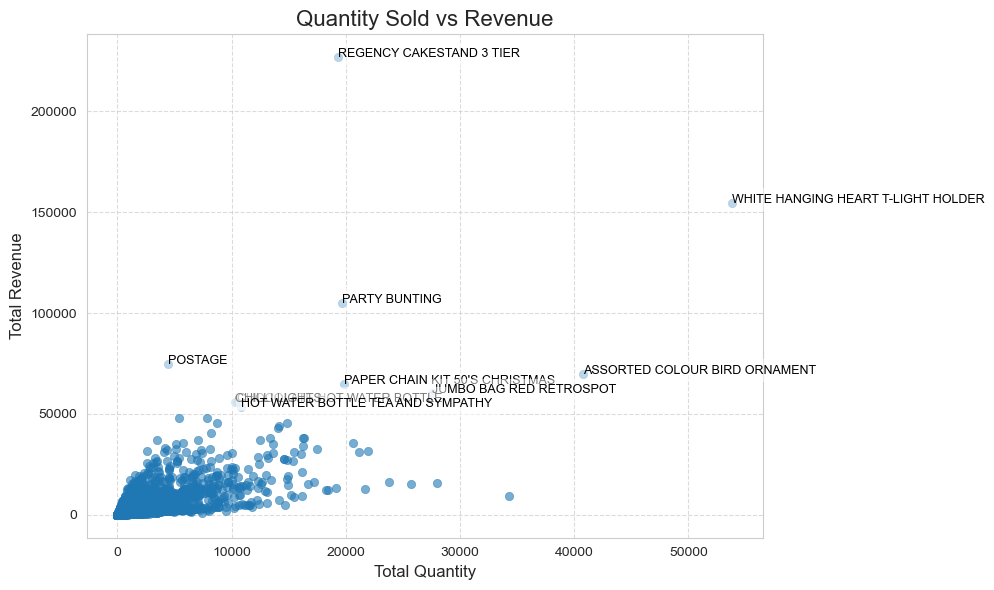

In [31]:
# 3. Scatter plot: Quantity vs Revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df4, x='TotalQuantity', y='TotalSpending', alpha=0.6, edgecolor=None)
plt.title('Quantity Sold vs Revenue', fontsize=16)
plt.xlabel('Total Quantity', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

# Optional: Add labels for some interesting points (e.g., top 10 revenue items)
for i in range(10):
    item = top_10_revenue.iloc[i]
    plt.text(x=item['TotalQuantity'], y=item['TotalSpending'], s=item.name, 
             fontdict=dict(color='black', size=9),
             bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Task 5: Finding, based on customer-value and product-performance, segment of customers plus products we should target for a promotion to maximize revenue (Basic “target group + product” recommendation)

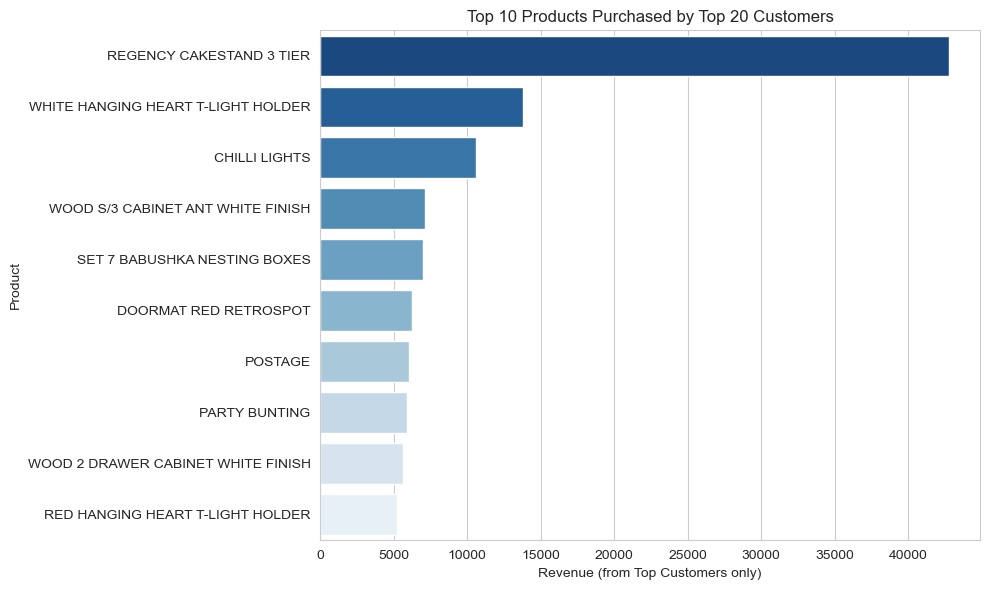

In [32]:
# --- TASK 1: Top 10 items purchased by Top Customers ---
# Filter original data to only include transactions from the top 20 customers
top_20_ids = top_20_customers.index  # Pull top 20 customers from part 3
top_cust_transactions = df_filtered[df_filtered['Customer ID'].isin(top_20_ids)]

# Aggregate revenue by product for this specific group
top_cust_product_revenue = top_cust_transactions.groupby('Description')['Total Price'].sum()
top_10_cust_favs = top_cust_product_revenue.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_cust_favs.values, y=top_10_cust_favs.index, palette='Blues_r')
plt.title('Top 10 Products Purchased by Top 20 Customers')
plt.xlabel('Revenue (from Top Customers only)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

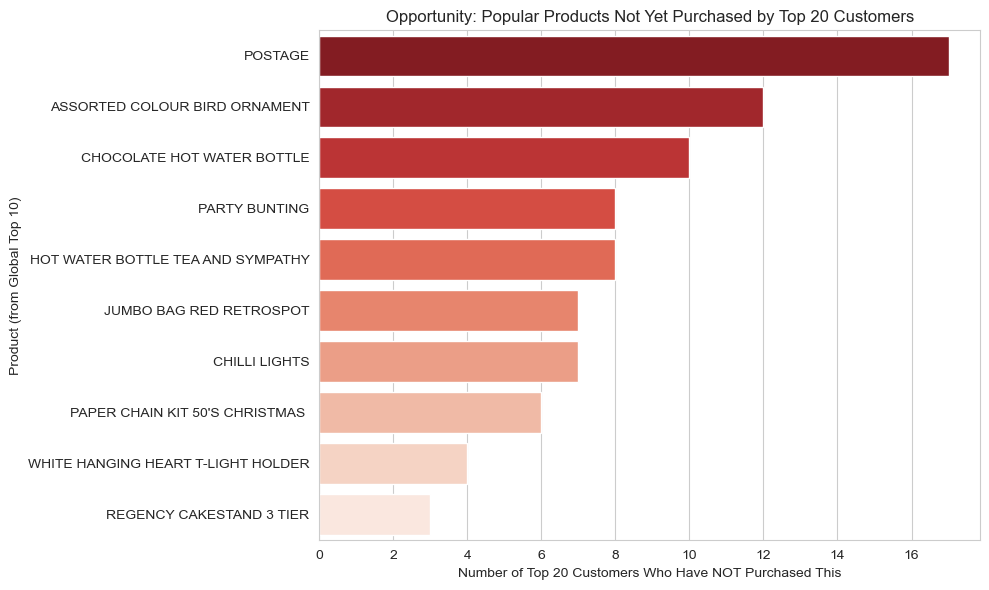

In [33]:
# --- TASK 2: Opportunity Analysis ---
# We want to check which of the "Global Top 10" are missing from the "Top 20 Customers" history.

# 1. Get the list of Global Top 10 Products (pull 'list to promote' from part 4)
global_top_10_names = top_10_revenue.index.tolist()

# 2. Build a matrix: Rows = Top Customers, Columns = Global Top 10 Products
# We use a pivot table to quickly check existence (count > 0)
relevant_transactions = top_cust_transactions[top_cust_transactions['Description'].isin(global_top_10_names)]

purchase_matrix = relevant_transactions.pivot_table(
    index='Customer ID', 
    columns='Description', 
    values='Total Price', 
    aggfunc='count'
).fillna(0)

# Reindex to ensure we include ALL top 20 customers and ALL global top 10 products
# (in case some customers bought NONE of the top 10, or some top 10 were bought by NONE of the top 20)
purchase_matrix = purchase_matrix.reindex(index=top_20_ids, columns=global_top_10_names, fill_value=0)

# 3. Calculate "Misses"
# Convert to True (Bought) / False (Not Bought)
has_bought = purchase_matrix > 0
# Sum the 'False' values to count how many customers missed it
missed_counts = (~has_bought).sum().sort_values(ascending=False)

# Filter out products that EVERYONE has bought (count 0)
opportunity_list = missed_counts[missed_counts > 0]

plt.figure(figsize=(10, 6))
sns.barplot(x=opportunity_list.values, y=opportunity_list.index, palette='Reds_r')
plt.title('Opportunity: Popular Products Not Yet Purchased by Top 20 Customers')
plt.xlabel('Number of Top 20 Customers Who Have NOT Purchased This')
plt.ylabel('Product (from Global Top 10)')
plt.tight_layout()
plt.show()

### END